# EDA — Data Room (revisão pré-protótipo)

Revisão16/09/2026: cálculos de decisão importam `prototipo/core.py`. As explorações históricas de perfil/dispersão mantidas nos primeiros blocos usam a janela completa e não são números de2023 sem filtro. As tabelas governadas seguintes declaram população e janela.

Reexecução requer o projeto com `prototipo/` e `data-room/`; saídas são regeneradas após revisão. Original preservado em backup. A tese vigente e o escopo das três camadas estão em `solucao/ESPECIFICACAO_PROTOTIPO.md`.


## 0 · Método

O ciclo de trabalho é perfilar → tratar → explorar → testar hipóteses → sintetizar. A revisão separa verificações estruturais, descrições contábeis e hipóteses causais ainda sem validação.

Perfil e dispersão históricos usam a janela completa explicitada no carregamento. A partir das tabelas governadas, os resultados usam B/2023 por padrão, com A declarada onde necessário. Dois registros truncados conhecidos são removidos; pedidos não aprovados e devolvidos continuam disponíveis na população A. Margens negativas legítimas são preservadas.

O núcleo compartilhado calcula indicadores; a IA auxilia consultas e interpretação. Comparação estratificada não é experimento. Uma conclusão depende do desenho da análise, não apenas de a conta ter sido executada em código.


## 1 · Hipóteses e status

A queda de rentabilidade do briefing é qualitativa. Investigamos desconto, economia de canal, custos pós-venda, aquisição e estoque. Diferença descritiva não comprova causa. O quadro revisado no bloco11 separa observação sustentada, conclusão não identificável e hipótese inconclusiva. Nenhuma hipótese é declarada anterior aos dados sem registro temporal verificável.


---
## 2 · Preparação dos dados

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

def achar_data_room():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "data-room").is_dir():
            return base / "data-room"
    raise FileNotFoundError(
        "Pasta 'data-room' não encontrada a partir de " + str(Path.cwd()) + ".\n"
        "Este notebook já vem com todas as saídas salvas: para apenas LER, não execute as células.\n"
        "Para reexecutar, coloque a pasta 'data-room/' ao lado do notebook (ou, no Colab, "
        "monte o Drive e ajuste RAIZ para o caminho da pasta).")

RAIZ = achar_data_room()
carregar = lambda nome: pd.read_csv(RAIZ / f"{nome}.csv", encoding="utf-8-sig")
print(f"data-room localizado: {len(list(RAIZ.glob('*.csv')))} arquivos .csv")

vendas      = carregar("vendas")
clientes    = carregar("clientes")
marketing   = carregar("marketing")
atendimento = carregar("atendimento")
estoque     = carregar("estoque")

BASES = {"vendas": vendas, "clientes": clientes, "marketing": marketing,
         "atendimento": atendimento, "estoque": estoque}

print("Linhas brutas por base")
for nome, df in BASES.items():
    print(f"  {nome:<12} {len(df):>7,} linhas  ×  {df.shape[1]:>2} colunas")
print(f"\n  {'TOTAL':<12} {sum(len(d) for d in BASES.values()):>7,} linhas")

data-room localizado: 5 arquivos .csv
Linhas brutas por base
  vendas        27,759 linhas  ×  20 colunas
  clientes      15,000 linhas  ×  14 colunas
  marketing      3,500 linhas  ×  15 colunas
  atendimento   35,841 linhas  ×  12 colunas
  estoque        5,000 linhas  ×  16 colunas

  TOTAL         87,100 linhas


In [2]:
# Paleta e helpers de gráfico
TINTA, TINTA_2, TINTA_3 = "#141821", "#3D4553", "#6B7383"   # textos
REGUA, PAPEL            = "#DCDFE5", "#FFFFFF"              # grades e fundo
AZUL, AZUL_CL           = "#1F3A6E", "#8FA8CE"              # acento
VERDE, AMBAR, VERMELHO  = "#1F6B4A", "#8A5A12", "#8E2F2A"   # semânticos
CINZA                   = "#B6BBC5"                          # contexto, sem destaque

mpl.rcParams.update({
    "figure.facecolor": PAPEL, "axes.facecolor": PAPEL, "savefig.facecolor": PAPEL,
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.edgecolor": REGUA, "axes.linewidth": .8,
    "axes.labelcolor": TINTA_2, "axes.labelsize": 10,
    "axes.titlesize": 12.5, "axes.titleweight": "semibold",
    "axes.titlecolor": TINTA, "axes.titlepad": 14, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": REGUA, "grid.linewidth": .7, "grid.alpha": .55,
    "axes.axisbelow": True,
    "xtick.color": TINTA_3, "ytick.color": TINTA_3,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": TINTA_2,
    "axes.prop_cycle": mpl.cycler(color=[AZUL, "#4E6E9E", "#7B93B8", AMBAR, VERDE, VERMELHO, CINZA]),
})

def limpar(ax, eixo="y"):
    # remove as molduras e deixa só a grade do eixo que ajuda a ler os valores
    for lado in ["top", "right", "left", "bottom"]:
        ax.spines[lado].set_visible(False)
    ax.grid(axis=eixo, visible=True)
    ax.grid(axis=("x" if eixo == "y" else "y"), visible=False)
    return ax

def nota(ax, texto, y=-0.20):
    # a leitura de negócio, não a descrição do que está desenhado
    ax.annotate(texto, xy=(0, y), xycoords="axes fraction",
                fontsize=9, color=TINTA_3, va="top", ha="left")

def rotular(ax, barras, fmt="{:.1f}", desloc=0, cor=None, tam=9):
    for b in barras:
        h = b.get_height()
        ax.annotate(fmt.format(h), xy=(b.get_x() + b.get_width()/2, h + desloc),
                    ha="center", va="bottom", fontsize=tam, color=cor or TINTA_2, fontweight="medium")

def brl(x, pos=None):
    if abs(x) >= 1e6: return f"R$ {x/1e6:,.1f} mi".replace(",", "X").replace(".", ",").replace("X", ".")
    if abs(x) >= 1e3: return f"R$ {x/1e3:,.0f} mil".replace(",", ".")
    return f"R$ {x:,.0f}".replace(",", ".")

def milhar(x, pos=None):
    return f"{x:,.0f}".replace(",", ".")

pd.set_option("display.width", 190, "display.max_columns", 60,
              "display.float_format", lambda v: f"{v:,.2f}")
print("estilo aplicado")

estilo aplicado


In [3]:
# Limpeza
# 1: atendimento tem uma linha lixo no fim do arquivo
lixo = atendimento[atendimento.drop(columns="ticket_id").isna().all(axis=1)]
print(f"atendimento: {len(lixo)} linha lixo removida -> {lixo.ticket_id.tolist()}")
atendimento = atendimento.drop(index=lixo.index).reset_index(drop=True)

# 2: vendas tem 1 linha com todos os campos numéricos nulos
nulas = vendas[vendas.quantidade.isna()]
print(f"vendas: {len(nulas)} linha sem valores numéricos removida")
vendas = vendas.dropna(subset=["quantidade"]).reset_index(drop=True)

# 3: tipagem e colunas derivadas (só conversão)
vendas["dt"]         = pd.to_datetime(vendas.data_pedido)
vendas["mes"]        = vendas.dt.dt.to_period("M")
vendas["devolvido"]  = vendas.devolvido.astype(str).str.lower().eq("true")
vendas["aprovado"]   = vendas.status_pagamento.eq("Aprovado")
vendas["desc_pct"]   = vendas.desconto_reais / vendas.receita_bruta
vendas["com_desc"]   = vendas.desc_pct > 0

atendimento["dt"]    = pd.to_datetime(atendimento.data_abertura)
marketing["dt_ini"]  = pd.to_datetime(marketing.data_inicio)

# recorte de pedido aprovado e não devolvido. usado só onde comparamos
# rentabilidade entre dimensões
vendas_limpas = vendas[vendas.aprovado & ~vendas.devolvido]

print(f"\nBase analítica: {len(vendas):,} pedidos  |  recorte limpo: {len(vendas_limpas):,} pedidos "
      f"({len(vendas_limpas)/len(vendas)*100:.1f}%)")
print(f"Janela: {vendas.dt.min():%d/%m/%Y} a {vendas.dt.max():%d/%m/%Y}  "
      f"({(vendas.dt.max()-vendas.dt.min()).days} dias)")
# Fundação revisada para os blocos de decisão
import sys
ROOT = RAIZ.parent
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from prototipo.core import DataRoom, Scope
room = DataRoom(ROOT)
A2023 = room.select(Scope(population="A"))
B2023 = room.select()


atendimento: 1 linha lixo removida -> ['TKT']
vendas: 1 linha sem valores numéricos removida

Base analítica: 27,758 pedidos  |  recorte limpo: 20,815 pedidos (75.0%)
Janela: 01/01/2023 a 26/01/2024  (390 dias)


### 2.1 · Grão, janela e vínculos
Vendas tem um pedido por linha e um SKU; quantidade são unidades. Atendimento tem vários tickets possíveis por pedido. Estoque é fotografia sem data. A e B são populações explícitas, não “base correta” versus “base errada”. Chaves existentes não garantem equivalência semântica.


In [4]:
# Pergunta 1 — GRÃO: o que é uma linha em cada base?
grao = []
for nome, df, chave in [("vendas", vendas, "order_id"), ("clientes", clientes, "customer_id"),
                        ("marketing", marketing, "campanha_id"), ("atendimento", atendimento, "ticket_id"),
                        ("estoque", estoque, "sku_id")]:
    grao.append({"base": nome, "linhas": len(df), "chave": chave,
                 "chaves únicas": df[chave].nunique(),
                 "1 linha = 1 chave": "sim" if df[chave].nunique() == len(df) else "NÃO"})
grao = pd.DataFrame(grao).set_index("base")

# vendas: um pedido pode ter vários itens?
itens_por_pedido = vendas.order_id.value_counts()

# Pergunta 2 — PERÍODO E COMPLETUDE: a série está fechada?
periodo = []
for nome, df, col in [("vendas", vendas, "data_pedido"), ("atendimento", atendimento, "data_abertura"),
                      ("marketing", marketing, "data_inicio"), ("clientes", clientes, "data_cadastro")]:
    d = pd.to_datetime(df[col]); m = d.dt.to_period("M")
    esperados = pd.period_range(m.min(), m.max(), freq="M")
    periodo.append({"base": nome, "início": d.min().date(), "fim": d.max().date(),
                    "meses": m.nunique(), "meses faltando": len(esperados) - m.nunique(),
                    "dias no último mês": d[m == m.max()].dt.day.nunique()})
periodo = pd.DataFrame(periodo).set_index("base")

display(grao.style.set_caption("<b>1 · Grão</b> — o que uma linha representa"))
display(periodo.style.set_caption("<b>2 · Período e completude</b> — a série está fechada?"))

print(f"vendas: itens por pedido → mínimo {itens_por_pedido.min()}, máximo {itens_por_pedido.max()}")
print(f"        {len(vendas):,} linhas para {vendas.order_id.nunique():,} pedidos distintos\n")
ult = vendas.mes.max()
print(f"último mês de vendas ({ult}): {vendas[vendas.mes == ult].dt.dt.day.nunique()} dias corridos, "
      f"{(vendas.mes == ult).sum():,} pedidos")
print(f"média dos 12 meses fechados: {vendas[vendas.mes != ult].groupby('mes').size().mean():,.0f} pedidos/mês")

,linhas,chave,chaves únicas,1 linha = 1 chave
base,,,,
vendas,27758,order_id,27758,sim
clientes,15000,customer_id,15000,sim
marketing,3500,campanha_id,3500,sim
atendimento,35840,ticket_id,35840,sim
estoque,5000,sku_id,5000,sim


,início,fim,meses,meses faltando,dias no último mês
base,,,,,
vendas,2023-01-01,2024-01-26,13,0,26
atendimento,2023-01-01,2025-12-31,36,0,31
marketing,2023-01-01,2025-12-28,36,0,27
clientes,2020-01-01,2025-12-28,72,0,28


vendas: itens por pedido → mínimo 1, máximo 1
        27,758 linhas para 27,758 pedidos distintos

último mês de vendas (2024-01): 26 dias corridos, 1,220 pedidos
média dos 12 meses fechados: 2,212 pedidos/mês


---
## 3 · Perfil das bases

Analisar quantas linhas, que colunas, que tipos, quantos nulos, quantos valores distintos tem as bases do Data Room.

In [5]:
def perfilar(df, nome):
    p = pd.DataFrame({
        "tipo":    df.dtypes.astype(str),
        "nulos":   df.isna().sum(),
        "%nulos":  (df.isna().mean()*100).round(2),
        "únicos":  df.nunique(),
        "%únicos": (df.nunique()/len(df)*100).round(2),
    })
    p.index.name = f"{nome}  ({len(df):,} linhas)"
    return p

for nome, df in BASES.items():
    display(perfilar(df, nome).style
            .background_gradient(subset=["%nulos"], cmap="Reds", vmin=0, vmax=100)
            .set_caption(f"<b>{nome}.csv</b>")
            .format({"%nulos":"{:.2f}", "%únicos":"{:.2f}"}))

,tipo,nulos,%nulos,únicos,%únicos
"vendas (27,759 linhas)",,,,,
order_id,str,0,0.00,27759,100.00
customer_id,str,0,0.00,346,1.25
sku_id,str,0,0.00,4918,17.72
data_pedido,str,0,0.00,27748,99.96
canal,str,0,0.00,7,0.03
categoria,str,0,0.00,4,0.01
produto,str,0,0.00,3418,12.31
quantidade,float64,1,0.00,6,0.02
preco_unitario,float64,1,0.00,19176,69.08


,tipo,nulos,%nulos,únicos,%únicos
"clientes (15,000 linhas)",,,,,
customer_id,str,0,0.00,15000,100.00
nome_completo,str,0,0.00,12654,84.36
data_nascimento,str,0,0.00,6420,42.80
genero,str,0,0.00,4,0.03
estado,str,0,0.00,27,0.18
cidade,str,0,0.00,137,0.91
nivel_fidelidade,str,0,0.00,4,0.03
data_cadastro,str,0,0.00,2016,13.44
opt_in_newsletter,bool,0,0.00,2,0.01


,tipo,nulos,%nulos,únicos,%únicos
"marketing (3,500 linhas)",,,,,
campanha_id,str,0,0.00,3500,100.00
nome_campanha,str,0,0.00,936,26.74
canal,str,0,0.00,7,0.20
categoria_foco,str,0,0.00,5,0.14
data_inicio,str,0,0.00,980,28.00
data_fim,str,0,0.00,983,28.09
investimento_reais,float64,0,0.00,3499,99.97
impressoes,int64,0,0.00,3500,100.00
cliques,int64,0,0.00,3491,99.74


,tipo,nulos,%nulos,únicos,%únicos
"atendimento (35,841 linhas)",,,,,
ticket_id,str,0,0.00,35841,100.00
customer_id,str,1,0.00,445,1.24
order_id,str,1,0.00,28589,79.77
data_abertura,str,1,0.00,35830,99.97
data_fechamento,str,1,0.00,26863,74.95
canal_entrada,str,1,0.00,5,0.01
categoria_problema,str,1,0.00,6,0.02
status_atendimento,str,1,0.00,4,0.01
texto_cliente,str,1,0.00,30,0.08


,tipo,nulos,%nulos,únicos,%únicos
"estoque (5,000 linhas)",,,,,
sku_id,str,0,0.00,5000,100.00
nome_produto,str,0,0.00,3450,69.00
categoria,str,0,0.00,4,0.08
subcategoria,str,0,0.00,48,0.96
fornecedor_id,str,0,0.00,100,2.00
lead_time_reposicao,int64,0,0.00,27,0.54
custo_unitario,float64,0,0.00,4708,94.16
preco_venda_sugerido,float64,0,0.00,4897,97.94
estoque_fisico,int64,0,0.00,925,18.50


**Leitura:** completude e tipos são verificações estruturais. Ausência de nulos não comprova origem sintética ou qualidade semântica. Custos padronizados e textos repetidos exigem avaliação específica.


---
## 4 · Integridade referencial
Ligar a venda ao cliente que comprou, ao SKU que saiu do estoque, ao ticket que foi aberto depois. Essas ligações são feitas por **chaves**: colunas que aparecem em duas bases e deveriam casar (`customer_id`, `sku_id`, `order_id`).

In [6]:
def cobertura(esq, dir_, chave, nome_esq, nome_dir):
    e = esq[chave].dropna()
    orfas = (~e.isin(dir_[chave])).sum()
    return {
        "relação":        f"{nome_esq}.{chave} → {nome_dir}",
        "linhas":         len(e),
        "chaves únicas":  e.nunique(),
        "órfãs":          orfas,
        "% órfãs":        round(orfas/len(e)*100, 1),
        "cobertura do destino": f"{e.nunique()}/{dir_[chave].nunique()} "
                                f"({e.nunique()/dir_[chave].nunique()*100:.1f}%)",
    }

testes = [
    cobertura(vendas,      clientes, "customer_id", "vendas",      "clientes"),
    cobertura(atendimento, clientes, "customer_id", "atendimento", "clientes"),
    cobertura(vendas,      estoque,  "sku_id",      "vendas",      "estoque"),
    cobertura(atendimento, vendas,   "order_id",    "atendimento", "vendas"),
]
mapa = pd.DataFrame(testes).set_index("relação")
display(mapa.style
        .background_gradient(subset=["% órfãs"], cmap="Reds", vmin=0, vmax=70)
        .set_caption("<b>Matriz de integridade referencial</b>, em que 'órfãs' = linhas cuja chave não existe na base de destino"))

,linhas,chaves únicas,órfãs,% órfãs,cobertura do destino
relação,,,,,
vendas.customer_id → clientes,27758,346,0,0.000000,346/15000 (2.3%)
atendimento.customer_id → clientes,35840,445,0,0.000000,445/15000 (3.0%)
vendas.sku_id → estoque,27758,4918,0,0.000000,4918/5000 (98.4%)
atendimento.order_id → vendas,35840,28589,23436,65.400000,28589/27758 (103.0%)


**Vínculos:** IDs permitem integração estrutural de Vendas/Clientes/Estoque. Históricos de Clientes requerem reconciliação. Atendimento requer cliente e cronologia além de order_id; o cálculo validado usa os três critérios.


In [7]:
# As duas bases compartilham o mesmo universo de clientes, ou se encontram por acaso?
cli_v = set(vendas.customer_id.unique())
cli_a = set(atendimento.customer_id.unique())
esperado = len(cli_v) * len(cli_a) / len(clientes)   # se fossem sorteios independentes do cadastro

print("POOL DE CLIENTES")
print(f"  vendas {len(cli_v)}  |  atendimento {len(cli_a)}  |  interseção {len(cli_v & cli_a)}")
print(f"  esperado sob sorteio independente de {len(clientes):,} cadastros: {esperado:.1f}")
print(f"  observado / esperado = {len(cli_v & cli_a)/esperado:.1f}x\n")

# Onde o order_id cruza, as duas bases concordam sobre QUEM é o cliente?
par = atendimento.merge(vendas[["order_id","customer_id"]], on="order_id",
                        how="inner", suffixes=("_at","_ven"))
bate = par.customer_id_at == par.customer_id_ven
print("CONCORDÂNCIA DE IDENTIDADE")
print(f"  tickets que cruzam com um pedido: {len(par):,} ({len(par)/len(atendimento)*100:.1f}%)")
print(f"  customer_id idêntico nas duas bases: {bate.sum():,} ({bate.mean()*100:.2f}%)")
print(f"  divergências: {(~bate).sum()}\n")

# A não-cobertura é explicada pela janela de vendas?
at_ano = atendimento.assign(cruza=atendimento.order_id.isin(set(vendas.order_id)))
print("COBERTURA POR ANO DO TICKET")
for ano, g in at_ano.groupby(at_ano.dt.dt.year):
    print(f"  {ano}: {len(g):>6,} tickets  |  cruzam {g.cruza.sum():>5,} ({g.cruza.mean()*100:4.1f}%)")
print("\n  vendas cobre 13 meses de um histórico de 3 anos: tickets sobre pedidos")
print("  não observados podem limitar a cobertura. Isso não prova que toda ausência de vínculo seja temporal.")
print("  A qualidade também exige verificar cliente e cronologia; o modelo governado aplica os três critérios.")

POOL DE CLIENTES
  vendas 346  |  atendimento 445  |  interseção 297
  esperado sob sorteio independente de 15,000 cadastros: 10.3
  observado / esperado = 28.9x

CONCORDÂNCIA DE IDENTIDADE
  tickets que cruzam com um pedido: 12,404 (34.6%)
  customer_id idêntico nas duas bases: 12,404 (100.00%)
  divergências: 0

COBERTURA POR ANO DO TICKET
  2023: 11,977 tickets  |  cruzam 5,798 (48.4%)
  2024: 12,116 tickets  |  cruzam 3,391 (28.0%)
  2025: 11,747 tickets  |  cruzam 3,215 (27.4%)

  vendas cobre 13 meses de um histórico de 3 anos: tickets sobre pedidos
  não observados podem limitar a cobertura. Isso não prova que toda ausência de vínculo seja temporal.
  A qualidade também exige verificar cliente e cronologia; o modelo governado aplica os três critérios.


**Interpretação:** concordância de customer_id entre pedidos e tickets é evidência estrutural; não valida todo o conteúdo. Aplicar cronologia e declarar cobertura. Não inferir o processo gerador dos dados apenas de concentração ou correlação.


In [8]:
pc = vendas.customer_id.value_counts()
display(pc.head(10).rename("pedidos observados por ID").to_frame())
print("Concentração de IDs não comprova identidade incorreta; reconciliar semântica cadastral.")


,pedidos observados por ID
customer_id,
CLI-11830,11282
CLI-01729,5664
CLI-14211,1664
CLI-12360,980
CLI-03910,966
CLI-02474,634
CLI-06160,623
CLI-07163,475
CLI-10455,454


Concentração de IDs não comprova identidade incorreta; reconciliar semântica cadastral.


---
## 5 · Coerência interna

Testar se as colunas calculadas de uma base batem com as colunas de origem. Em `vendas`, três identidades precisam valer em toda linha:

```
receita_bruta   = quantidade × preço_unitário
receita_líquida = receita_bruta − desconto
margem          = receita_líquida − custo_produto − custo_frete
```


In [9]:
TOL = 0.05   # tolerância exploratória de campos arredondados; núcleo financeiro valida até 1 centavo

identidades = {
    "vendas: receita_bruta = quantidade × preço":
        (vendas.receita_bruta - vendas.quantidade*vendas.preco_unitario).abs(),
    "vendas: receita_líquida = bruta − desconto":
        (vendas.receita_liquida - (vendas.receita_bruta - vendas.desconto_reais)).abs(),
    "vendas: margem = líquida − custo − frete":
        (vendas.margem_contribuicao - (vendas.receita_liquida - vendas.custo_produto - vendas.custo_frete)).abs(),
    "estoque: disponível = físico − reservado":
        (estoque.estoque_disponivel - (estoque.estoque_fisico - estoque.estoque_reservado)).abs(),
    "marketing: ROAS = receita_gerada / investimento":
        (marketing.roas - marketing.receita_gerada/marketing.investimento_reais).abs(),
    "marketing: campo cac = investimento / conversões (sem validar aquisição)":
        (marketing.cac - marketing.investimento_reais/marketing.conversoes.replace(0, np.nan)).abs(),
}

res = pd.DataFrame([
    {"identidade": k, "linhas testadas": v.notna().sum(),
     "quebras": int((v > TOL).sum()), "% quebras": round((v > TOL).mean()*100, 2),
     "veredito": "consistente" if (v > TOL).sum() == 0 else "QUEBRA"}
    for k, v in identidades.items()
]).set_index("identidade")

display(res.style.map(lambda x: f"color:{VERDE};font-weight:600" if x == "consistente"
                      else f"color:{VERMELHO};font-weight:600", subset=["veredito"])
        .set_caption("<b>Testes de coerência aritmética</b>"))

# condições para revisão; margem negativa pode ser legítima
print("Condições observadas para revisão (não são automaticamente erros)")
for rot, cond in {
    "receita líquida ≤ 0":            vendas.receita_liquida <= 0,
    "desconto > receita bruta":        vendas.desconto_reais > vendas.receita_bruta,
    "tempo de entrega negativo":       vendas.tempo_entrega_real < 0,
    "quantidade ≤ 0":                  vendas.quantidade <= 0,
    "margem negativa":                 vendas.margem_contribuicao < 0,
}.items():
    print(f"  {rot:<32} {cond.sum():>6,}   ({cond.mean()*100:5.2f}%)")

,linhas testadas,quebras,% quebras,veredito
identidade,,,,
vendas: receita_bruta = quantidade × preço,27758,0,0.000000,consistente
vendas: receita_líquida = bruta − desconto,27758,0,0.000000,consistente
vendas: margem = líquida − custo − frete,27758,0,0.000000,consistente
estoque: disponível = físico − reservado,5000,0,0.000000,consistente
marketing: ROAS = receita_gerada / investimento,3500,0,0.000000,consistente
marketing: campo cac = investimento / conversões (sem validar aquisição),3500,0,0.000000,consistente


Condições observadas para revisão (não são automaticamente erros)
  receita líquida ≤ 0                   0   ( 0.00%)
  desconto > receita bruta              0   ( 0.00%)
  tempo de entrega negativo             0   ( 0.00%)
  quantidade ≤ 0                        0   ( 0.00%)
  margem negativa                     491   ( 1.77%)


**Coerência:** identidades aritméticas não validam semântica financeira. Margem negativa é possível e não deve ser removida por conveniência. O campo CAC reproduz custo por conversão, não necessariamente aquisição de cliente.


---
## 6 · Distribuição, dispersão e atípicos

Antes de comparar médias entre grupos, é preciso saber se a média representa alguém. Três resumos da mesma coluna dão três números diferentes, e a diferença entre eles é informação.


In [10]:
v = vendas_limpas.copy()
v["mg_pct"] = v.margem_contribuicao / v.receita_liquida * 100

# Três resumos da mesma coluna. Eles não coincidem, e a diferença é a informação.
resumo = pd.DataFrame({
    "margem % do pedido": [v.mg_pct.mean(), v.mg_pct.median(), v.mg_pct.std(),
                           v.mg_pct.std()/v.mg_pct.mean(), v.mg_pct.skew()],
    "ticket (R$)":        [v.receita_liquida.mean(), v.receita_liquida.median(), v.receita_liquida.std(),
                           v.receita_liquida.std()/v.receita_liquida.mean(), v.receita_liquida.skew()],
}, index=["média", "mediana", "desvio-padrão", "coef. de variação", "assimetria"])

razao = v.margem_contribuicao.sum() / v.receita_liquida.sum() * 100

# Critério de atípico: IQR de Tukey (Q1 - 1,5·IQR ; Q3 + 1,5·IQR)
def tukey(s):
    q1, q3 = s.quantile(.25), s.quantile(.75); iqr = q3 - q1
    li, ls = q1 - 1.5*iqr, q3 + 1.5*iqr
    return q1, q3, iqr, li, ls, ((s < li) | (s > ls))

q1, q3, iqr, li, ls, fora = tukey(v.mg_pct)
tq1, tq3, tiqr, tli, tls, tfora = tukey(v.receita_liquida)

display(resumo.style.format("{:,.2f}").set_caption("<b>Tendência central e dispersão</b>"))
print(f"margem — Q1 {q1:.1f}%  Q3 {q3:.1f}%  IQR {iqr:.1f} p.p.  limites [{li:.1f}% , {ls:.1f}%]")
print(f"         atípicos: {fora.sum():,} pedidos ({fora.mean()*100:.1f}%), todos abaixo do limite inferior: "
      f"{(v.mg_pct[fora] < li).all()}")
print(f"ticket — Q1 R$ {tq1:,.0f}  Q3 R$ {tq3:,.0f}  limite sup. R$ {tls:,.0f}  "
      f"atípicos: {tfora.sum():,} ({tfora.mean()*100:.1f}%)")
print(f"\nmargem agregada (soma da margem ÷ soma da receita) = {razao:.1f}%")
print(f"média das margens de cada pedido                    = {v.mg_pct.mean():.1f}%")
print(f"mediana das margens de cada pedido                  = {v.mg_pct.median():.1f}%")

,margem % do pedido,ticket (R$)
média,49.63,680.69
mediana,53.72,540.44
desvio-padrão,16.76,532.97
coef. de variação,0.34,0.78
assimetria,-2.43,1.65


margem — Q1 43.7%  Q3 60.7%  IQR 17.0 p.p.  limites [18.2% , 86.2%]
         atípicos: 999 pedidos (4.8%), todos abaixo do limite inferior: True
ticket — Q1 R$ 285  Q3 R$ 931  limite sup. R$ 1,901  atípicos: 685 (3.3%)

margem agregada (soma da margem ÷ soma da receita) = 54.4%
média das margens de cada pedido                    = 49.6%
mediana das margens de cada pedido                  = 53.7%


findfont: Failed to find font weight semibold, now using 700.


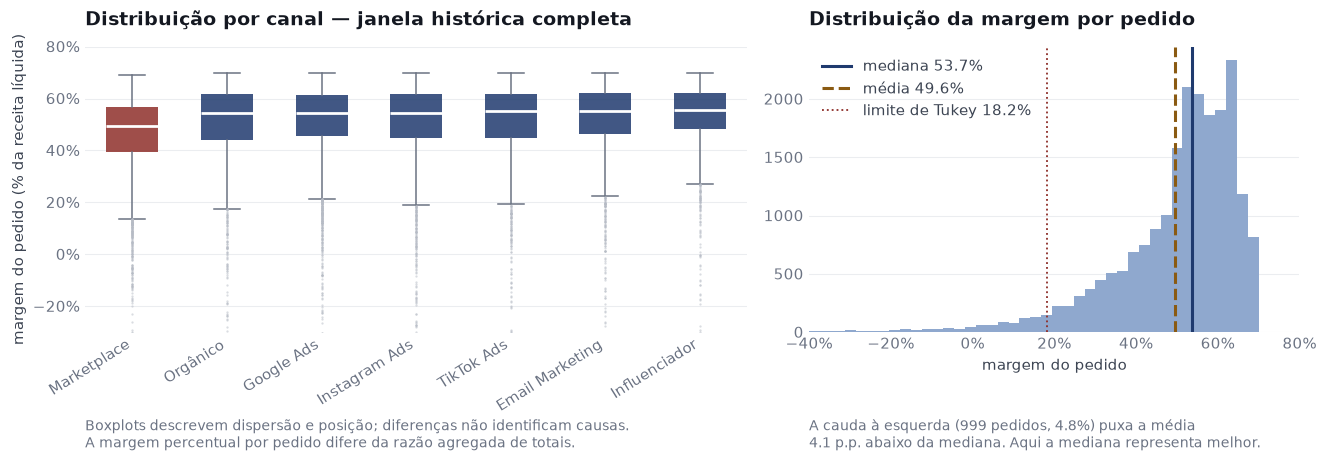

In [11]:
ordem = v.groupby("canal").mg_pct.median().sort_values().index.tolist()
dados = [v.loc[v.canal == c, "mg_pct"].values for c in ordem]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.6), gridspec_kw={"width_ratios": [1.35, 1]})

bp = ax1.boxplot(dados, patch_artist=True, widths=.55, showfliers=True,
                 flierprops=dict(marker=".", ms=3, mfc=CINZA, mec="none", alpha=.5),
                 medianprops=dict(color=PAPEL, lw=1.8),
                 whiskerprops=dict(color=TINTA_3, lw=1), capprops=dict(color=TINTA_3, lw=1))
for i, caixa in enumerate(bp["boxes"]):
    caixa.set(facecolor=VERMELHO if ordem[i] == "Marketplace" else AZUL, alpha=.85, lw=0)
ax1.set_xticks(range(1, len(ordem)+1), ordem, rotation=32, ha="right")
ax1.set_ylabel("margem do pedido (% da receita líquida)")
ax1.yaxis.set_major_formatter(PercentFormatter())
ax1.set_ylim(-30, 80)
ax1.set_title("Distribuição por canal — janela histórica completa")
limpar(ax1, "y")
nota(ax1, "Boxplots descrevem dispersão e posição; diferenças não identificam causas.\n"
          "A margem percentual por pedido difere da razão agregada de totais.", y=-0.30)

ax2.hist(v.mg_pct, bins=90, color=AZUL_CL, edgecolor="none")
ax2.axvline(v.mg_pct.median(), color=AZUL, lw=2, label=f"mediana {v.mg_pct.median():.1f}%")
ax2.axvline(v.mg_pct.mean(), color=AMBAR, lw=2, ls="--", label=f"média {v.mg_pct.mean():.1f}%")
ax2.axvline(li, color=VERMELHO, lw=1.2, ls=":", label=f"limite de Tukey {li:.1f}%")
ax2.set_xlim(-40, 80); ax2.set_xlabel("margem do pedido")
ax2.xaxis.set_major_formatter(PercentFormatter())
ax2.set_title("Distribuição da margem por pedido")
ax2.legend(loc="upper left")
limpar(ax2, "y")
nota(ax2, f"A cauda à esquerda ({fora.sum():,} pedidos, {fora.mean()*100:.1f}%) puxa a média\n"
          f"{v.mg_pct.median()-v.mg_pct.mean():.1f} p.p. abaixo da mediana. Aqui a mediana representa melhor.", y=-0.30)
plt.tight_layout(); plt.show()

**Distribuições:** razão de totais mede margem agregada; média e mediana por pedido respondem perguntas diferentes. Atípicos legítimos permanecem. Semelhança de distribuições não comprova igualdade operacional ou ausência de causas.


## 7 · Variação por tempo e dimensão
As tabelas abaixo usam B/2023. Desvios são descritivos. Não há evidência suficiente para atribuir a queda de rentabilidade completa a um único componente.


### 7.1 · Série temporal
Meses completos de2023; MC% por razão de totais. Uma observação anual não basta para comprovar sazonalidade recorrente.


,grupo,pedidos,receita_bruta,desconto_reais,receita_liquida,custo_produto,custo_frete,margem_contribuicao,mc_pct
0,2023-01,1046,"761,026.62","52,723.30","708,303.32","307,261.49","12,737.01","388,304.82",54.82
1,2023-02,1033,"754,244.89","58,609.02","695,635.87","305,406.99","12,700.71","377,528.17",54.27
2,2023-03,2358,"1,833,745.11","143,033.99","1,690,711.12","740,109.18","27,712.39","922,889.55",54.59
3,2023-04,1132,"866,668.50","67,348.18","799,320.32","350,797.23","13,310.06","435,213.03",54.45
4,2023-05,2688,"1,932,191.79","144,183.18","1,788,008.61","779,450.21","32,992.74","975,565.66",54.56
5,2023-06,1154,"863,264.48","64,052.59","799,211.89","345,602.86","13,897.02","439,712.01",55.02
6,2023-07,1152,"860,831.77","69,683.54","791,148.23","345,507.04","14,236.33","431,404.86",54.53
7,2023-08,1215,"900,281.28","74,712.45","825,568.83","364,105.27","13,706.04","447,757.52",54.24
8,2023-09,1283,"956,100.12","69,257.40","886,842.72","385,278.16","14,444.43","487,120.13",54.93
9,2023-10,1273,"934,856.70","80,847.77","854,008.93","377,121.99","15,642.93","461,244.01",54.01


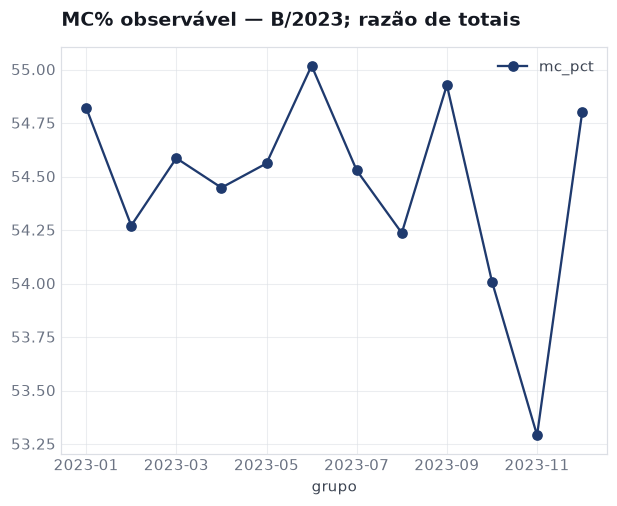

In [12]:
mensal = pd.DataFrame(room.breakdown("mes")["valores"]["grupos"])
display(mensal)
mensal.plot(x="grupo",y="mc_pct",marker="o",title="MC% observável — B/2023; razão de totais"); plt.show()


In [13]:
bf = A2023[A2023.dt.dt.strftime("%Y-%m-%d").eq("2023-11-24")]
fr = A2023[A2023.dt.dt.month.eq(11) & A2023.dt.dt.dayofweek.eq(4) & A2023.dt.dt.day.ne(24)]
print({"populacao":"A/2023","pedidos_BF":len(bf),"media_pedidos_outras_sextas_novembro":float(fr.groupby(fr.dt.dt.date).size().mean()),"mc_registrada_BF":round(bf.margem_contribuicao.sum(),2)})
print("Comparação descritiva; não identifica efeito causal do desconto.")


{'populacao': 'A/2023', 'pedidos_BF': 466, 'media_pedidos_outras_sextas_novembro': 125.33333333333333, 'mc_registrada_BF': np.float64(126902.88)}
Comparação descritiva; não identifica efeito causal do desconto.


**Leitura:** comparar períodos e componentes não identifica o resultado alternativo sem promoção. Novembro e Black Friday são sinais de investigação, não experimentos.


In [14]:
for dimensao in ["canal","categoria","metodo_pagamento"]:
    print(dimensao,"B/2023")
    display(pd.DataFrame(room.breakdown(dimensao)["valores"]["grupos"]))


canal B/2023


,grupo,pedidos,receita_bruta,desconto_reais,receita_liquida,custo_produto,custo_frete,margem_contribuicao,mc_pct
0,Email Marketing,2029,"1,456,207.75","106,679.56","1,349,528.19","587,433.26","14,002.76","748,092.17",55.43
1,Google Ads,3928,"2,855,134.47","243,862.42","2,611,272.05","1,152,942.15","25,410.88","1,432,919.02",54.87
2,Influenciador,1619,"1,597,189.40","136,883.48","1,460,305.92","646,236.68","6,195.15","807,874.09",55.32
3,Instagram Ads,3572,"2,575,202.30","207,323.18","2,367,879.12","1,041,179.78","23,623.53","1,303,075.81",55.03
4,Marketplace,4307,"3,095,525.15","239,424.41","2,856,100.74","1,245,588.30","139,724.26","1,470,788.18",51.50
5,Orgânico,2344,"1,689,568.99","129,373.46","1,560,195.53","680,737.33","16,966.28","862,491.92",55.28
6,TikTok Ads,2104,"1,485,941.48","117,295.41","1,368,646.07","595,868.85","15,117.40","757,659.82",55.36


categoria B/2023


,grupo,pedidos,receita_bruta,desconto_reais,receita_liquida,custo_produto,custo_frete,margem_contribuicao,mc_pct
0,Acessórios,2904,"2,087,207.37","167,442.60","1,919,764.77","836,425.62","36,158.30","1,047,180.85",54.55
1,Beleza,6004,"4,400,278.42","347,197.00","4,053,081.42","1,774,271.60","74,235.97","2,204,573.85",54.39
2,Lifestyle,4011,"3,010,055.46","243,667.14","2,766,388.32","1,220,582.09","48,764.00","1,497,042.23",54.12
3,Moda,6984,"5,257,228.29","422,535.18","4,834,693.11","2,118,707.04","81,881.99","2,634,104.08",54.48


metodo_pagamento B/2023


,grupo,pedidos,receita_bruta,desconto_reais,receita_liquida,custo_produto,custo_frete,margem_contribuicao,mc_pct
0,Boleto,3001,"2,266,168.31","181,868.23","2,084,300.08","913,900.87","35,146.80","1,135,252.41",54.47
1,Cartão de Crédito,9983,"7,393,020.30","588,091.08","6,804,929.22","2,981,190.56","120,861.63","3,702,877.03",54.41
2,PIX,6001,"4,432,892.06","359,648.15","4,073,243.91","1,787,754.59","73,569.77","2,211,919.55",54.30
3,Vale-Troca,918,"662,688.87","51,234.46","611,454.41","267,140.33","11,462.06","332,852.02",54.44


In [15]:
display(pd.DataFrame(room.breakdown("canal")["valores"]["grupos"])[["grupo","pedidos","mc_pct"]])


,grupo,pedidos,mc_pct
0,Email Marketing,2029,55.43
1,Google Ads,3928,54.87
2,Influenciador,1619,55.32
3,Instagram Ads,3572,55.03
4,Marketplace,4307,51.50
5,Orgânico,2344,55.28
6,TikTok Ads,2104,55.36


## 8 · Decomposição e comparação estratificada
Diferenças dentro de estratos não provam efeito causal. O frete é componente da identidade contábil; sua origem operacional permanece a validar.


In [16]:
comparacao = room.stratified("canal","com_desc")
display(pd.DataFrame(comparacao["valores"]["grupos"]))
print(comparacao["limitacoes"])


,grupo,estrato,pedidos,mc_pct
0,Email Marketing,False,1359,58.99
1,Email Marketing,True,670,46.47
2,Google Ads,False,2450,58.84
3,Google Ads,True,1478,46.47
4,Influenciador,False,1026,59.32
5,Influenciador,True,593,46.49
6,Instagram Ads,False,2315,58.83
7,Instagram Ads,True,1257,46.09
8,Marketplace,False,2759,55.40
9,Marketplace,True,1548,41.85


['Não é teste de causalidade. Sobrevivência ou desaparecimento de diferença não prova causa.', 'Ausência de grupos em estratos limita a comparação; não implica que duas variáveis sejam idênticas.']


**Leitura:** mesmo após estratificar por desconto, diferenças podem permanecer por outros fatores. Grupos ausentes limitam comparação; não declarar “causa real” a partir de amplitude.


In [17]:
d = B2023.copy()
d["faixa250"] = np.where(d.receita_liquida <250,"<250",">=250")
display(d.groupby(["canal","faixa250"]).agg(pedidos=("order_id","size"),frete_medio=("custo_frete","mean"),fracao_com_frete=("com_frete","mean")))
print("Custo registrado, não cobrança ao cliente; política ainda não confirmada.")


pedidos  frete_medio  fracao_com_frete
canal           faixa250                                        
Email Marketing <250          442        31.68              1.00
                >=250        1587         0.00              0.00
Google Ads      <250          775        32.79              1.00
                >=250        3153         0.00              0.00
Influenciador   <250          194        31.93              1.00
                >=250        1425         0.00              0.00
Instagram Ads   <250          741        31.88              1.00
                >=250        2831         0.00              0.00
Marketplace     <250          970        32.68              1.00
                >=250        3337        32.37              1.00
Orgânico        <250          519        32.69              1.00
                >=250        1825         0.00              0.00
TikTok Ads      <250          459        32.94              1.00
                >=250        1645         0.00              0.00

Custo registrado, não cobrança ao cliente; política ainda não confirmada.


**Frete:** valor registrado para a empresa, não cobrança ao cliente. Padrão no limiar não confirma política nem ganho ao aumentar ticket. Fretes positivos variam entre pedidos.


In [18]:
triagem = B2023[(B2023.receita_bruta>=250)&(B2023.receita_liquida<250)]
print({"pedidos":len(triagem),"frete_registrado":round(triagem.custo_frete.sum(),2),"classificacao":"triagem descritiva, não saving"})
display(pd.DataFrame(room.breakdown("faixa_ticket")["valores"]["grupos"]))


{'pedidos': 584, 'frete_registrado': np.float64(18555.03), 'classificacao': 'triagem descritiva, não saving'}


,grupo,pedidos,receita_bruta,desconto_reais,receita_liquida,custo_produto,custo_frete,margem_contribuicao,mc_pct
0,"(100,250]",3375,"690,479.68","85,148.90","605,330.78","273,246.03","109,164.62","222,920.13",36.83
1,"(250,500]",5137,"2,135,441.59","243,607.13","1,891,834.46","851,428.57","34,752.89","1,005,653.00",53.16
2,"(500,1000]",6323,"5,024,721.28","469,550.81","4,555,170.47","2,004,324.00","43,395.32","2,507,451.15",55.05
3,>1000,4342,"6,840,229.19","372,163.23","6,468,065.96","2,795,816.43","29,877.95","3,642,371.58",56.31
4,até 100,726,"63,897.80","10,371.85","53,525.95","25,171.32","23,849.48","4,505.15",8.42


**Triagem:** receita bruta>=250 e líquida<250 identifica pedidos para investigação. Não é cobrança indevida nem frete evitável comprovado.


### 8.1 · Implicação
A média esconde economias distintas. Isso justifica decompor e simular, não bloquear pedidos pequenos nem declarar custo fixo de processamento.


## 9 · Segmentação descritiva
Segmentos auxiliam investigação. Ação comercial, estabilidade e utilidade precisam ser validadas; não são automaticamente aprovadas por terem margens distintas.


In [19]:
rfm = B2023.groupby("customer_id").agg(pedidos=("order_id","size"),ultima_compra=("dt","max"),mc_observavel=("margem_contribuicao","sum"))
display(rfm.describe())
print("Resumo de IDs observados em B/2023; não é LTV histórico validado.")


,pedidos,ultima_compra,mc_observavel
count,300.00,300,300.00
mean,66.34,2023-09-16 03:22:59.610000,"24,609.67"
min,1.00,2023-01-01 11:56:04,-35.43
25%,1.00,2023-05-29 14:43:14.500000,311.39
50%,2.00,2023-11-10 08:01:55.500000,769.03
75%,6.00,2023-12-18 23:37:14.750000,"2,428.49"
max,"8,108.00",2023-12-31 23:48:33,"3,005,059.32"
std,530.16,NaN,"196,473.56"


Resumo de IDs observados em B/2023; não é LTV histórico validado.


**Clientes:** métricas descritivas sobre IDs observados são calculáveis. A interpretação individual e de longo prazo exige reconciliação dos cadastros, janela e identidade. Concentração sozinha não invalida RFM.


In [20]:
seg = B2023.groupby(["com_desc","com_frete"]).agg(pedidos=("order_id","size"),receita=("receita_liquida","sum"),mc=("margem_contribuicao","sum"))
seg["mc_pct"] = 100*seg.mc/seg.receita
display(seg)


pedidos      receita           mc  mc_pct
com_desc com_frete                                           
False    False         8316 7,191,888.49 4,291,433.38   59.67
         True          4503 2,321,921.54 1,245,469.65   53.64
True     False         4150 3,023,949.59 1,447,147.35   47.86
         True          2934 1,036,168.00   398,850.63   38.49

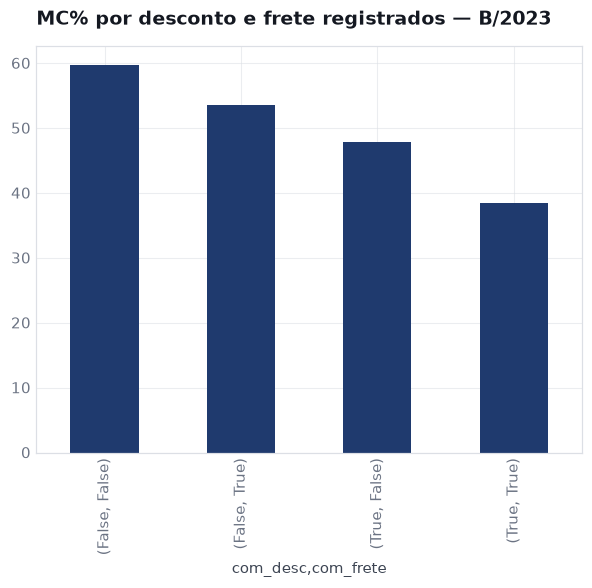

In [21]:
seg.mc_pct.plot.bar(title="MC% por desconto e frete registrados — B/2023"); plt.show()


**Leitura:** desconto e frete fazem parte da equação da margem. Separar grupos por esses componentes ajuda a descrever economia, mas não prova causalidade ou benefício de uma ação.


## 10 · Exposições e cenários
Valores de naturezas diferentes não formam um ranking de saving. Não calcular perda realizada de devoluções nem margem perdida de ruptura com snapshot sem data.


In [22]:
display(room.funnel())


{'tipo': 'status_pedidos',
 'versao_calculo': '1.0.0',
 'versao_contrato': '1.0.0',
 'hash_contrato': 'f677f3b2fd913046d6ff90c5777ce945e157fb8dde38558e3b20226384bc7294',
 'fontes_sha256': {'vendas.csv': '0199d2f3e06067985a658ab51e50568867ae2df97f65c98d1954ce3a9151cc62',
  'atendimento.csv': 'a61a52929e72a706b922267315b26affa594e73fa233ae94c93a151f72cdfaab'},
 'escopo': {'start': '2023-01-01',
  'end': '2023-12-31',
  'population': 'A',
  'channel': None,
  'category': None,
  'ticket_lt': None,
  'discounted_only': False},
 'valores': {'nao_aprovados': {'pedidos': 3150,
   'pct_pedidos': 11.869771648202578,
   'mc_registrada': 1157319.94},
  'aprovados_devolvidos': {'pedidos': 3485,
   'pct_pedidos': 13.132112442535233,
   'mc_registrada': 1292710.99},
  'aprovados_sem_devolucao': {'pedidos': 19903,
   'pct_pedidos': 74.9981159092622,
   'mc_registrada': 7382901.01},
  'total_pedidos': 26538},
 'limitacoes': ['Grupos mutuamente exclusivos. MC fora de B não é perda realizada.',
  'Não s

**Interpretação:** status de pedido não determina todos os custos incorridos. MC fora de B é campo registrado; não é dedução adicional da MC de B.


### Ponto1 · Desconto e cenário de retenção
Diferenças históricas não mostram quanto volume ocorreria sem incentivo. O cenário usa retenção e mix constantes como premissas explícitas.


In [23]:
cenario = room.simulate_discount()
display(cenario)


{'tipo': 'cenario_condicional',
 'versao_calculo': '1.0.0',
 'versao_contrato': '1.0.0',
 'hash_contrato': 'f677f3b2fd913046d6ff90c5777ce945e157fb8dde38558e3b20226384bc7294',
 'fontes_sha256': {'vendas.csv': '0199d2f3e06067985a658ab51e50568867ae2df97f65c98d1954ce3a9151cc62',
  'atendimento.csv': 'a61a52929e72a706b922267315b26affa594e73fa233ae94c93a151f72cdfaab'},
 'escopo': {'start': '2023-01-01',
  'end': '2023-12-31',
  'population': 'B',
  'channel': None,
  'category': None,
  'ticket_lt': 250,
  'discounted_only': True},
 'valores': {'pedidos_elegiveis': 1852,
  'pedidos_com_alteracao': 1852,
  'mc_base': 73913.06,
  'reducao_desconto_se_todos_retidos': 95520.75,
  'mc_com_retencao_integral': 169433.81,
  'mc_cenario': 169433.81,
  'delta_mc_cenario': 95520.75,
  'retencao_equilibrio': 0.4362356013832186,
  'retencao_assumida': 1.0,
  'fracao_desconto_removida': 1.0,
  'pedidos_esperados_sob_premissa': 1852.0,
  'status': 'cenario_condicional',
  'guardrails': {'mc_agregada_cenari

In [24]:
sensibilidade = pd.DataFrame([room.simulate_discount(retention=r)["valores"] for r in [0,.25,.4362356013832186,.5,.75,1]])
display(sensibilidade[["retencao_assumida","mc_base","mc_cenario","delta_mc_cenario"]])


,retencao_assumida,mc_base,mc_cenario,delta_mc_cenario
0,0.00,"73,913.06",0.00,"-73,913.06"
1,0.25,"73,913.06","42,358.45","-31,554.61"
2,0.44,"73,913.06","73,913.06",0.00
3,0.50,"73,913.06","84,716.91","10,803.85"
4,0.75,"73,913.06","127,075.36","53,162.30"
5,1.00,"73,913.06","169,433.81","95,520.75"


### Ponto2 · Atendimento: volume e custo registrado
Sem prazo prometido, tempo real de entrega não mede atraso. Categoria de ticket não determina causa nem evitabilidade.


In [25]:
a23 = room.tickets[room.tickets.dt_ticket.dt.year.eq(2023)]
display(a23.groupby("categoria_problema").agg(tickets=("ticket_id","size"),custo_registrado=("custo_operacional_ticket","sum")))


,tickets,custo_registrado
categoria_problema,,
Defeito,2174,"32,778.00"
Dúvida Técnica,1741,"26,413.00"
Elogio,1222,"18,064.00"
Onde está meu pedido?,3656,"54,371.00"
Pagamento não aprovado,1407,"21,436.00"
Troca de Tamanho,1777,"26,309.00"


**Próximas hipóteses:** comunicação, rastreabilidade e self-service podem ser testados. Frequência de tickets não é percentual de automação garantido.


### Ponto3 · Custo padronizado por canal
Comparação descritiva; complexidade e escalonamento não estão controlados. Não interpretar custo menor como substituição possível com igual qualidade.


In [26]:
display(a23.groupby("canal_entrada").agg(tickets=("ticket_id","size"),custo_padronizado=("custo_operacional_ticket","mean"),csat_medio=("nota_csat","mean")))
print("Não controla severidade; custos padronizados não são saving de migração.")


,tickets,custo_padronizado,csat_medio
canal_entrada,,,
ChatBot,2378,2.00,3.27
E-mail,3004,15.00,3.24
Reclame Aqui,1021,45.00,3.31
Telefone,1371,15.00,3.30
WhatsApp,4203,15.00,3.18


Não controla severidade; custos padronizados não são saving de migração.


### Ponto4 · Devoluções
Motivos registrados orientam investigação, mas não comprovam que70% são recuperáveis. Não inferir custos incorridos, reembolso ou valor recuperado.


In [27]:
dev = A2023[A2023.aprovado & A2023.devolvido]
display(dev.groupby("motivo_devolucao").agg(pedidos=("order_id","size"),mc_registrada=("margem_contribuicao","sum")))
print("MC registrada em devolvidos, não perda econômica realizada.")


,pedidos,mc_registrada
motivo_devolucao,,
Arrependimento,487,"177,577.01"
Atraso na entrega,679,"245,078.81"
Não gostei,566,"218,046.92"
Produto com defeito,877,"337,660.90"
Tamanho errado,876,"314,347.35"


MC registrada em devolvidos, não perda econômica realizada.


### Ponto5 · Estoque como fotografia
Status e lead time descrevem o snapshot. Não cruzar essa foto sem data com margem histórica para estimar perda ou exposição histórica causada por ruptura.


In [28]:
display(estoque.groupby("status_disponibilidade").agg(skus=("sku_id","size"),lead_time_mediano=("lead_time_reposicao","median")))
print("Fotografia sem data; nenhuma inferência sobre vendas históricas perdidas.")


,skus,lead_time_mediano
status_disponibilidade,,
Descontinuado,207,14.00
Em Estoque,3993,14.00
Estoque Crítico,701,13.00
Ruptura,99,52.00


Fotografia sem data; nenhuma inferência sobre vendas históricas perdidas.


**Limitação:** sem série temporal, não calcular vendas perdidas, giro ou causalidade histórica da ruptura. Lead time por status é apenas descrição da fotografia.


## 11 · Quadro revisado de hipóteses
O quadro não atribui validação causal a estatísticas descritivas. Para converter hipótese em política, é necessário desenho de validação adequado.


In [29]:
hipoteses = pd.DataFrame([
 ["H1-A","Desconto e menor MC% em novembro","Associação descritiva; sem causalidade"],
 ["H1-B","Efeito do desconto na MC total da BF","Não identificado; comparação entre datas não é contrafactual"],
 ["H1-C","Desconto ótimo","Não identificável sem resposta da demanda"],
 ["H2-A/B","Gap Marketplace e frete","Diferença e componente contábil observáveis"],
 ["H2-C/D","Mecanismo e parcela recuperável","Inconclusivos"],
 ["H3","MC explica rentabilidade completa","Métrica insuficiente para esse propósito"],
 ["H4","Perda e recuperação das devoluções","Não identificáveis com economia pós-venda ausente"],
 ["H5","Concentração e automação do atendimento","Concentração observável; evitabilidade inconclusiva"],
 ["EST","Ruptura explica perdas históricas","Não identificável com snapshot sem data"]
],columns=["ID","Pergunta","Status revisado"])
display(hipoteses)


,ID,Pergunta,Status revisado
0,H1-A,Desconto e menor MC% em novembro,Associação descritiva; sem causalidade
1,H1-B,Efeito do desconto na MC total da BF,Não identificado; comparação entre datas não é...
2,H1-C,Desconto ótimo,Não identificável sem resposta da demanda
3,H2-A/B,Gap Marketplace e frete,Diferença e componente contábil observáveis
4,H2-C/D,Mecanismo e parcela recuperável,Inconclusivos
5,H3,MC explica rentabilidade completa,Métrica insuficiente para esse propósito
6,H4,Perda e recuperação das devoluções,Não identificáveis com economia pós-venda ausente
7,H5,Concentração e automação do atendimento,Concentração observável; evitabilidade inconcl...
8,EST,Ruptura explica perdas históricas,Não identificável com snapshot sem data


**Síntese:** há diferenças econômicas observáveis e lacunas relevantes. A solução integra monitoramento, decomposição, simulação, explicação e decisão registrada.


## Anexo A · Clientes e Marketing
ROAS interno é calculável com ressalvas; CAC de novos clientes não está identificado. IDs/históricos de Clientes precisam de reconciliação. Não declarar fabricação independente a partir de baixa correlação.


In [30]:
pc = vendas.customer_id.nunique()
print({"IDs_com_pedido_observado":pc,"IDs_cadastrados":len(clientes)})
print("Sem pedido na janela não significa nunca comprou. Histórico e definições precisam de reconciliação.")


{'IDs_com_pedido_observado': 346, 'IDs_cadastrados': 15000}
Sem pedido na janela não significa nunca comprou. Histórico e definições precisam de reconciliação.


In [31]:
roas = marketing.receita_gerada.sum()/marketing.investimento_reais.sum()
print({"ROAS_interno_2023_2025":float(roas),"CAC_novos_clientes":"não calculável com definição disponível"})
print("Receita atribuída não reconciliada com Vendas; conversões não comprovadas como novos clientes.")


{'ROAS_interno_2023_2025': 4.175707346032019, 'CAC_novos_clientes': 'não calculável com definição disponível'}
Receita atribuída não reconciliada com Vendas; conversões não comprovadas como novos clientes.


In [32]:
print("Índice de share de MC / share de investimento retirado como recomendação de alocação: não há atribuição validada. ROAS e MC% medem conceitos diferentes.")


Índice de share de MC / share de investimento retirado como recomendação de alocação: não há atribuição validada. ROAS e MC% medem conceitos diferentes.


## Anexo B · Controles
Cálculos de decisão importam a fundação testada. Saídas históricas foram removidas/regeneradas para evitar contradições. Cálculo determinístico não garante interpretação correta; registrar limitações e revisar respostas de IA.
